In [7]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look nicer
plt.style.use("ggplot")
sns.set_theme()


In [ ]:
silver_path = "s3a://delta-lake-bucket/silver/sales_items"

df = pl.read_delta(
    "s3://lakehouse/silver/sales_items",
    storage_options={
        "AWS_ENDPOINT_URL": "http://[IP of MinIO]:9000",
        "AWS_REGION": "local",
        "AWS_S3_FORCE_PATH_STYLE": "true",
        "AWS_ALLOW_HTTP": "true",
    }
)

df.head()




store_id,customer_id,business_date,event_ts,isbn,title,genre,quantity,unit_price,line_total
str,str,date,"datetime[μs, UTC]",str,str,str,i32,f64,f64
"""madison""","""d163d185-69e1-47ce-bcc3-cddbd5…",2026-03-01,2026-03-01 15:17:44.711967 UTC,"""9780765376671""","""The Three-Body Problem""","""Sci-Fi""",1,17.99,17.99
"""madison""","""b6be18b8-3775-4060-9943-19f41a…",2026-03-01,2026-03-01 15:53:55.525719 UTC,"""9780374533557""","""Thinking, Fast And Slow""","""Non-Fiction""",1,30.52,30.52
"""madison""","""b6be18b8-3775-4060-9943-19f41a…",2026-03-01,2026-03-01 15:53:55.525719 UTC,"""9780590353427""","""Harry Potter and the Sorcerer'…","""Fantasy""",2,12.99,25.98
"""glendale""","""ca73ba26-fccc-4d0d-9313-409e9f…",2026-03-01,2026-03-01 15:13:35.976361 UTC,"""9781250183866""","""Extreme Ownership""","""Non-Fiction""",1,27.45,27.45
"""glendale""","""ca73ba26-fccc-4d0d-9313-409e9f…",2026-03-01,2026-03-01 15:13:35.976361 UTC,"""9780593309735""","""The Very Hungry Caterpillar""","""Children""",1,8.99,8.99


In [9]:
df = df.with_columns(
    pl.col("event_ts").dt.date().alias("event_date")
)


In [10]:
daily_sales = (
    df.group_by("business_date")
      .agg(pl.col("line_total").sum().alias("total_sales"))
      .sort("business_date")
)

daily_sales

business_date,total_sales
date,f64
2026-03-01,11904.2
2026-03-02,12959.12
2026-03-03,10997.73
2026-03-04,4485.08
2026-03-05,2836.91
…,…
2026-03-13,708.23
2026-03-14,5224.23
2026-03-15,13152.09


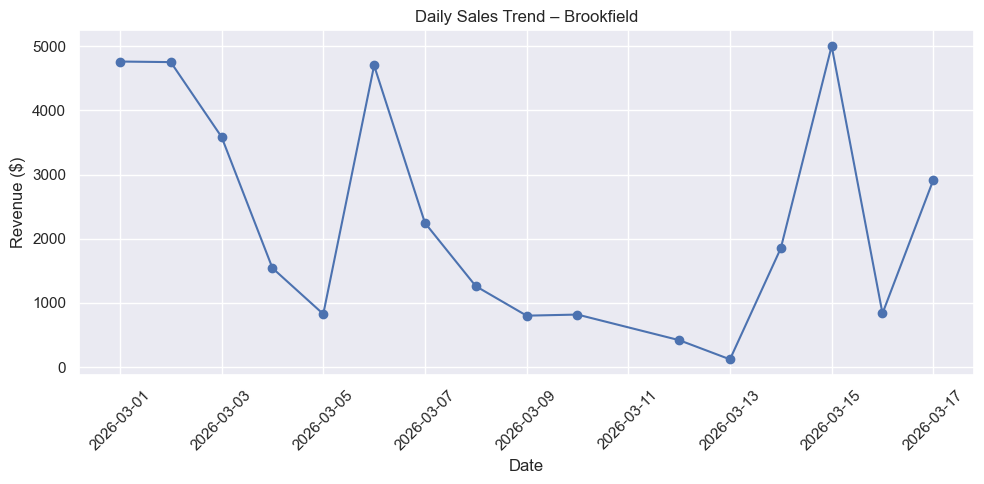

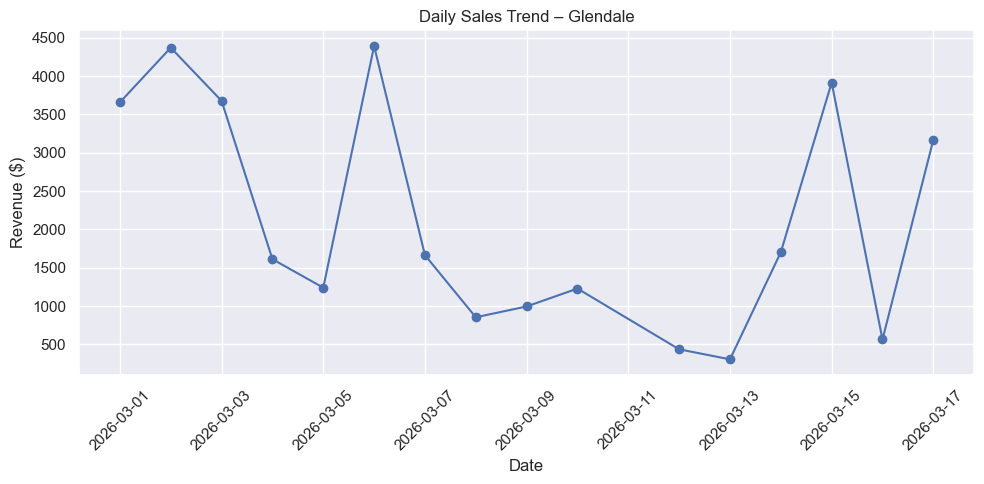

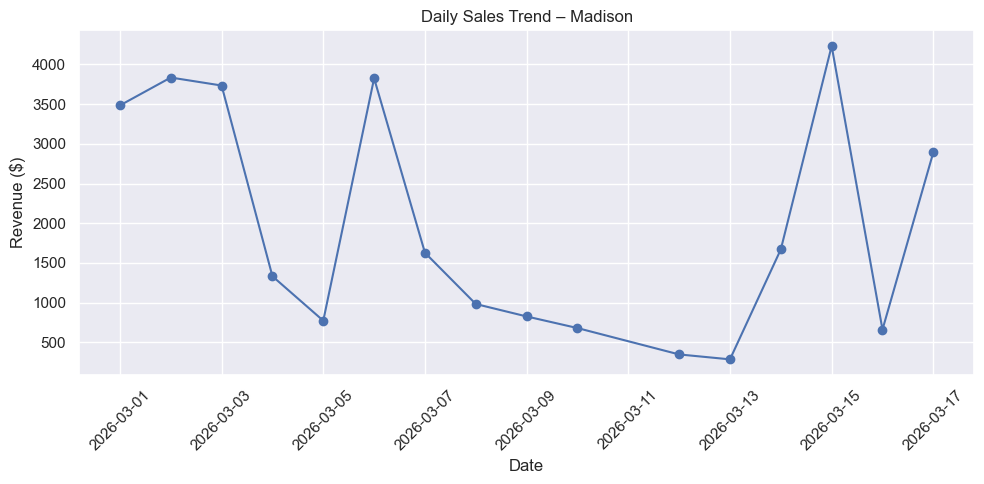

In [11]:
daily_sales_by_store = (
    df.group_by(["store_id", "event_date"])
      .agg(pl.col("line_total").sum().alias("total_sales"))
      .sort(["store_id", "event_date"])
)

pdf = daily_sales_by_store.to_pandas()
stores = pdf["store_id"].unique()

for store in stores:
    store_df = pdf[pdf["store_id"] == store]

    plt.figure(figsize=(10,5))
    plt.plot(store_df["event_date"], store_df["total_sales"], marker="o")
    plt.title(f"Daily Sales Trend – {store.capitalize()}")
    plt.xlabel("Date")
    plt.ylabel("Revenue ($)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [12]:
df.schema


Schema([('store_id', String),
        ('customer_id', String),
        ('business_date', Date),
        ('event_ts', Datetime(time_unit='us', time_zone='UTC')),
        ('isbn', String),
        ('title', String),
        ('genre', String),
        ('quantity', Int32),
        ('unit_price', Float64),
        ('line_total', Float64),
        ('event_date', Date)])